# 01 · Three-dimensional tracking, splits/merges, and periodic boundaries
Daily spatial patches linked by temporal overlap and direct three-dimensional connectivity define events differently. This notebook checks the former against fixtures generated by the original MATLAB implementation, then illustrates the distinction with a small example.
In each label map, white means no event and cells of the same color belong to one output event. Colors represent labels within the current case only.

In [1]:
include(isfile("bootstrap.jl") ? "bootstrap.jl" : "notebooks/bootstrap.jl")

  Activating 

project at `/Volumes/new_drive/lagrangian/julia/notebooks`


Julia 1

.12.3 | MHWTracking 0.1.0


## MATLAB references for periodic boundaries, splits, and merges
Parameters follow the source: daily 8-connectivity, first/last longitude connections, overlap divided by the smaller patch area, and a threshold of 0.5. The default minimum duration is 5 days.
Split branches remain in the existing event; pixels in a merged patch are distributed among existing events. Full fields and membership sets are validated before plotting, rather than choosing expected results from the colors.

In [2]:
fixture=matread(joinpath(ROOT,"test","fixtures","overlap.mat"))
selected=[findfirst(==(name),vec(fixture["names"])) for name in ["periodic","split","merge"]]
concept_masks=fixture["inputs"][selected]
concept_tracks=[track_mhw_3d(mask,vec(fixture["lon"]),vec(fixture["lat"])) for mask in concept_masks]
@testset "MATLAB periodic / split / merge" begin
    for (k,i) in enumerate(selected)
        expected=overlap_from_mat(fixture["outputs"][i])
        @test strict_overlap_equal(concept_tracks[k],expected)
        @test partition_equal(concept_tracks[k],expected,size(concept_masks[k]))
        println(fixture["names"][i],": ",length(concept_tracks[k])," tracks; splits=",
            [(t.split_day,t.split_num) for t in concept_tracks[k]])
    end
end

periodic: 

1 tracks; splits=[(Int64[], Int64[])]
split: 1 tracks; splits=[([5, 6, 7, 8], [2, 2, 2, 2])]
merge

: 2 tracks; splits=[(Int64[], Int64[]), (Int64[], Int64[])]
Test Summary:                   | 

Pass  Total  Time
MATLAB periodic / split / merge |    6      6  1.0s


Test.DefaultTestSet("MATLAB periodic / split / merge", Any[], 6, false, false, true, 1.791466639705499e9, 1.79146664067704e9, false, "In[2]", Random.Xoshiro(0x495166bc2dfd980b, 0x17f92552e7dfcf49, 0x463aed6267e57b58, 0xf7c0ad8e2fee347e, 0xb6a838843c9bde10))

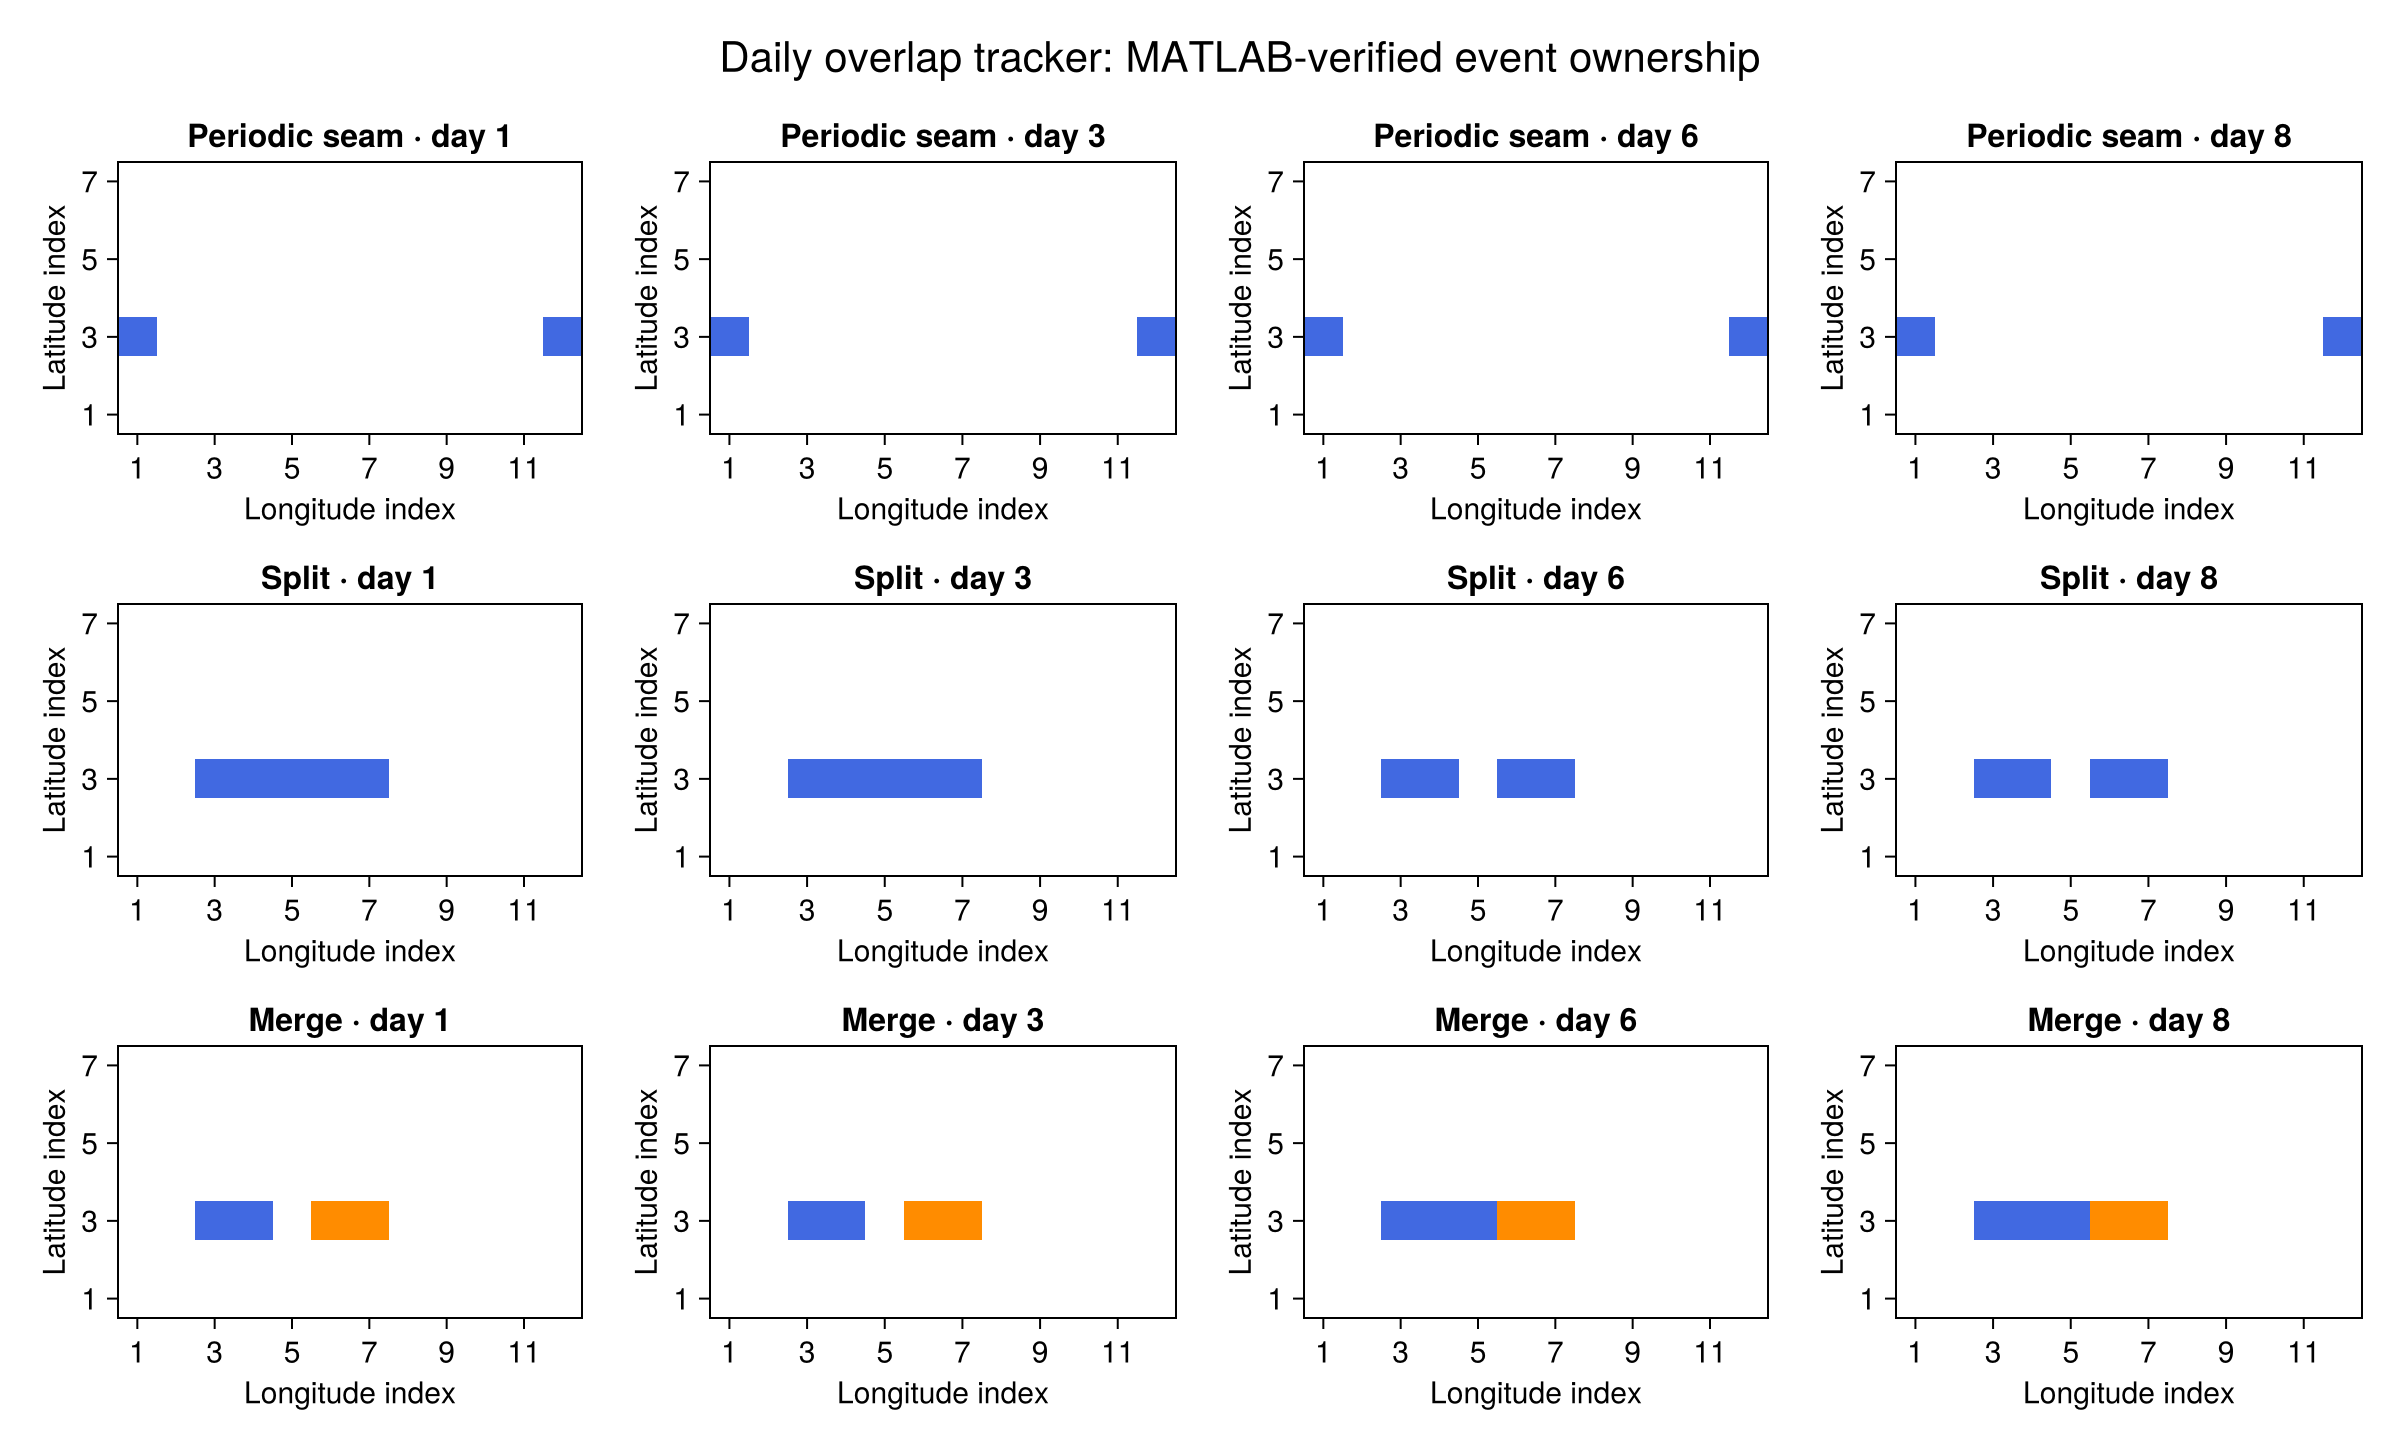

In [3]:
fig=Figure(size=(1200,720))
for (r,name) in enumerate(["Periodic seam","Split","Merge"])
    lab=labels(concept_tracks[r],size(concept_masks[r]))
    days=unique(round.(Int,range(1,size(lab,3);length=4)))
    for (c,day) in enumerate(days)
        label_panel(fig[r,c],lab[:,:,day];title="$name · day $day",maxlabel=length(concept_tracks[r]))
    end
end
Label(fig[0,:],"Daily overlap tracker: MATLAB-verified event ownership",fontsize=21)
emit_figure(fig,"01_overlap_evolution")

## Why the two three-dimensional methods differ
The two cells below occur on adjacent days at neighboring spatial locations but have no spatial overlap. Overlap tracking produces two events; direct 26-connectivity produces one.
The standalone three-dimensional MATLAB source was not supplied. Therefore, `track_mhw_3d_connected` is an explicitly documented 6/26-connectivity extension, not a claimed port of that missing file.

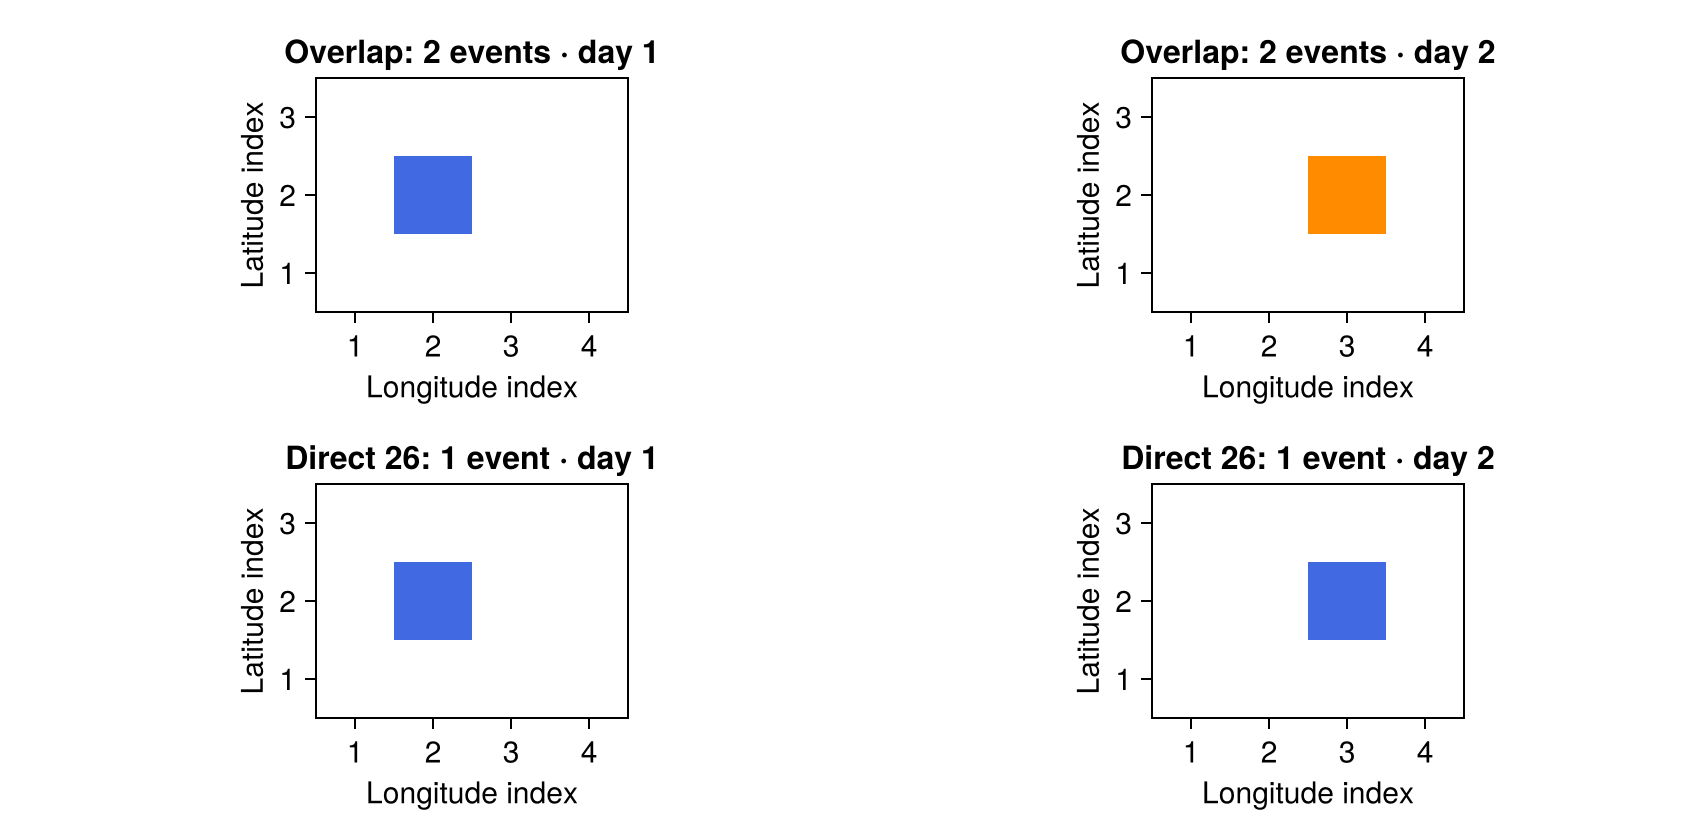

In [4]:
mask=falses(4,3,2); mask[2,2,1]=mask[3,2,2]=true
overlap=track_mhw_3d(mask,1:4,1:3;min_duration=1)
direct,_=track_mhw_3d_connected(mask;min_duration=1)
@test length(overlap)==2
@test length(direct)==1
fig=Figure(size=(850,420))
for (r,(name,result)) in enumerate([("Overlap: 2 events",overlap),("Direct 26: 1 event",direct)])
    lab=labels(result,size(mask))
    for day in 1:2
        label_panel(fig[r,day],lab[:,:,day];title="$name · day $day",maxlabel=2)
    end
end
emit_figure(fig,"01_method_difference")

## Preprocessing invalid values
The underlying functions retain MATLAB's nonzero-is-active semantics, including NaN. Explicitly binarize real data with the confirmed rule before tracking; do not pass the unprocessed continuous-valued field directly.

In [5]:
raw=reshape([NaN,-0.2,0.0,0.7,Inf,2.0],3,2)
positive=isfinite.(raw).&(raw.>0)
@test count(positive)==2
println("finite && value > 0 mask = ",positive)

finite && value > 0 mask = Bool

[0 1; 0 0; 0 1]
